In [1]:
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import os

In [37]:
nc_path = r"E:\04-Geneva_dummy\03_24h-wind_extended\crop_results\surface.nc"

In [38]:
ds = xr.open_dataset(nc_path)

In [39]:
resolution = 100
ds['XC'] = np.array(range(0,len(ds['XC'])))*resolution + resolution/2
ds['YC'] = np.array(range(0,len(ds['YC'])))*resolution + resolution/2
ds['XG'] = np.array(range(0,len(ds['XG'])))*resolution
ds['YG'] = np.array(range(0,len(ds['YG'])))*resolution

In [40]:
ds.VVEL.isel(time=-1).plot()

In [91]:
def plot_map(ds, i_time: int):
    plt.ioff()
    plt.close()
    fig, ax = plt.subplots(figsize=(15,11))

    T_plot = ds['time'].values[i_time]
    Z_plot = 0
    xr_plot = ds['THETA'].sel(time=T_plot)
    xr_plot = xr_plot.where(xr_plot != 0, np.nan)
    #xr_plot.plot(cmap='jet', vmin=12, vmax=18)
    xr_plot.plot(cmap='jet')
    plt.axis('equal')

    subsetting_factor = 7
    X_trimmed = ds['XC'][::subsetting_factor]
    Y_trimmed = ds['YC'][::subsetting_factor]
    U_trimmed = ds['UVEL'].sel(time=T_plot)[:,1:][::subsetting_factor,::subsetting_factor]
    V_trimmed = ds['VVEL'].sel(time=T_plot)[1:,:][::subsetting_factor,::subsetting_factor]

    U_trimmed = U_trimmed.where(U_trimmed != 0, np.nan)
    V_trimmed = V_trimmed.where(V_trimmed != 0, np.nan)
    plt.quiver(X_trimmed, Y_trimmed, U_trimmed, V_trimmed, scale=4)

    #xgrid, ygrid = np.meshgrid(X_trimmed, Y_trimmed)
    #plt.streamplot(xgrid, ygrid, U_trimmed, V_trimmed,
    #               density=7, color='black', linewidth=0.5,
    #               arrowsize=0.7, arrowstyle='->')

    plt.text(0.02, 0.98, f'{np.datetime_as_string(T_plot, unit="s").replace("T", " ")}', transform=plt.gca().transAxes, ha='left', va='top')
    plt.text(0.02, 0.9, f'Z={Z_plot}m', transform=plt.gca().transAxes, ha='left', va='top')
    plt.title('')

    x, y = np.meshgrid(ds['XC'].values, ds['YC'].values)
    u = ds['UVEL'].isel(time=i_time).values
    v = ds['VVEL'].isel(time=i_time).values
    plt.streamplot(x, y, u, v)

    # Remove axis, ticks, labels, and title
    #ax.set_xticks([])
    #ax.set_yticks([])
    #ax.set_xlim(left=15000, right=35000)
    #ax.set_ylim(bottom=7500, top=24000)
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    return plt.gcf()

In [92]:
i_time=24*5+10

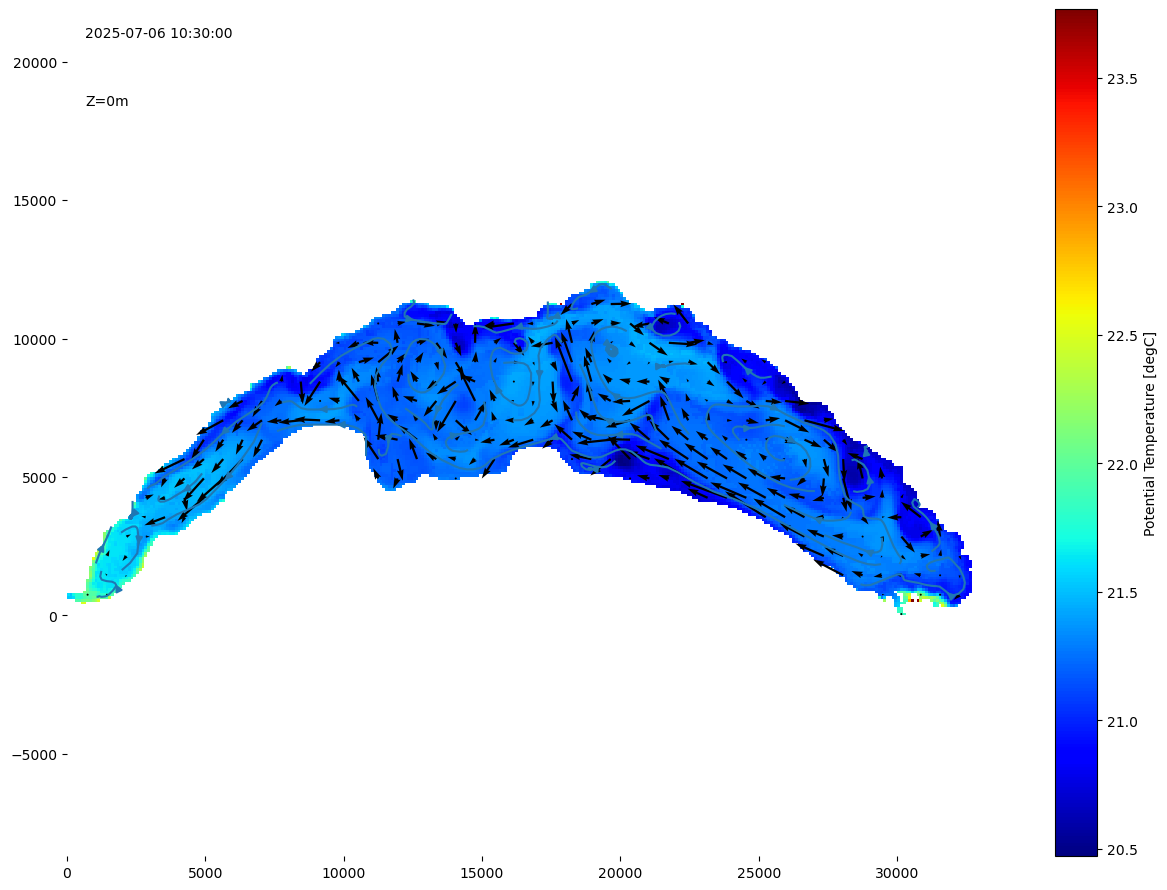

In [93]:
fig = plot_map(ds, i_time)
#plt.xlim(36000,50000)
#plt.ylim(20000,25000)
plt.show()
i_time+=1

In [94]:
ds_spatial_mean = ds.where(ds != 0, np.nan).mean(dim=['YC', 'XC', 'XG', 'YG'])

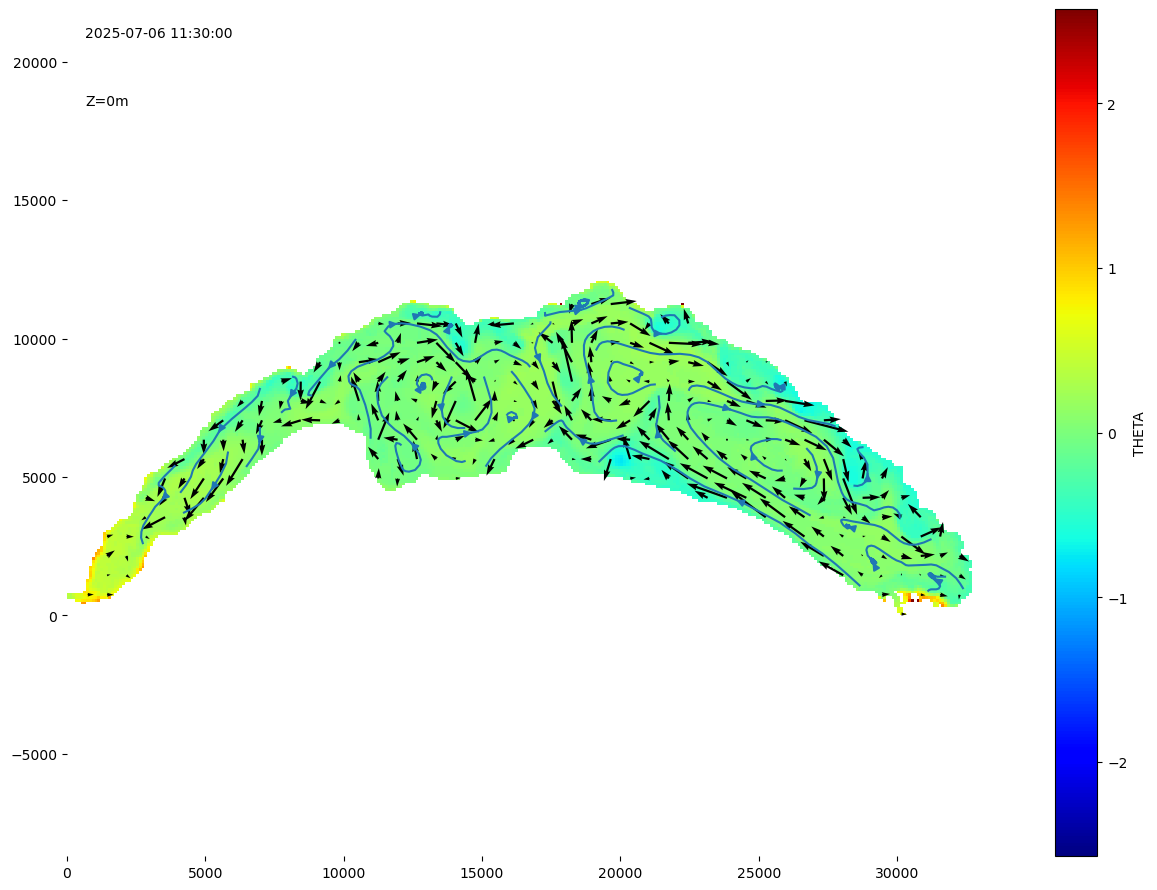

In [95]:
fig = plot_map(ds.where(ds != 0, np.nan)-ds_spatial_mean, i_time)
plt.show()

In [8]:
for i in range(0,len(ds.time),3):
    fig = plot_map(ds, i)
    fig.savefig(fr'E:\06-Madeline field trip\20260127\map_surface\map_forecast_{i:03d}.png')

map_folder_path = os.path.join(folder_path, "figures", "map_surface")
os.makedirs(map_folder_path, exist_ok=True)
for i in range(ds.sizes['time']):
    plot_map(ds, i)
    plt.savefig(os.path.join(map_folder_path, f"map_{i}.png"))

In [ ]:
squared_speed = ds['UVEL'].values**2+ds['VVEL'].values**2

In [ ]:
ke_tot = []
for t in range(len(ds.time)):
    ke_tot.append(0.5*squared_speed[t,:,:].sum()*200*200*0.5)

In [ ]:
plt.close()
plt.figure()
plt.plot(ke_tot)
plt.xlabel('time')
plt.ylabel('Kinematic Energy [J]')
plt.show()

In [ ]:
plt.close()
plt.figure()
ds.sel(XG=49850, YC = 18100, method = 'nearest').UVEL.plot()
plt.show()

In [ ]:
from PIL import Image
import io

In [ ]:
def plot_map_streamlines(i_time: int, stream_density, vmin, vmax, rotate_angle=None):
    plt.ioff()
    plt.close()
    fig, ax = plt.subplots(figsize=(20,7))

    T_plot = ds['time'].values[i_time]
    xr_plot = ds['THETA'].sel(time=T_plot)
    xr_plot = xr_plot.where(xr_plot != 0, np.nan)
    xr_plot.plot(cmap='jet', add_colorbar=True, vmin=vmin, vmax=vmax) #, vmin=vmin, vmax=vmax
    plt.axis('equal')

    xgrid, ygrid = np.meshgrid(ds['XC'], ds['YC'])
    plt.streamplot(xgrid, ygrid, ds['UVEL'].sel(time=T_plot), ds['VVEL'].sel(time=T_plot),
                   density=stream_density, color='black', linewidth=0.5,
                   arrowsize=0.7, arrowstyle='->')

    #plt.xlim(37500,42500)
    #plt.ylim(19500,24500)

    plt.text(0.2, 0.8, f'{np.datetime_as_string(T_plot, unit="s").replace("T", " ")}', transform=plt.gca().transAxes, ha='left', va='top')
    plt.text(0.2, 0.75, f'Z={0}m', transform=plt.gca().transAxes, ha='left', va='top')
    plt.title('')

    # Remove axis, ticks, labels, and title
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_xlabel("")
    ax.set_ylabel("")
    ax.set_title("")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)

    if rotate_angle is not None:
        buf = io.BytesIO()
        fig.savefig(buf, format='png', bbox_inches='tight')
        buf.seek(0)
        img = Image.open(buf)
        img = img.rotate(rotate_angle, expand=True)
        plt.close(fig)
        fig, ax = plt.subplots(figsize=(20,7))
        ax.imshow(img)
        ax.axis('off')

    return plt.gcf()

In [ ]:
idx_sat_imgs = [
    29*24-14,
    (31+3) * 24-14,
    (31+8) * 24-14,
    (31+13) * 24-14,
    (31+18) * 24-14,
    (31+23) * 24-14,
    (31+28) * 24-14,
    (31+30+3) * 24-14]

In [ ]:
for idx in idx_sat_imgs:
    img = plot_map_streamlines(idx, 4, 15, 20) #rotate_angle=19.4
    T_plot = ds['time'].values[idx]
    img.savefig(os.path.join(r"D:\03-eddy_detection\geneva_june_2023\figures\cal_lucerne", f"{np.datetime_as_string(T_plot, unit='D') }.png"))

In [ ]:
idx= idx_sat_imgs[-1]
img = plot_map_streamlines(idx, 4, 15, 20) #rotate_angle=19.4
T_plot = ds['time'].values[idx]
img.savefig(os.path.join(r"D:\03-eddy_detection\geneva_june_2023\figures\cal_lucerne", f"{np.datetime_as_string(T_plot, unit='D') }.png"))

In [ ]:
ds_sta = xr.open_dataset(r"D:\04-Geneva_dummy\02_24h-wind\crop_results\lexplore_depth_time.nc")

In [ ]:
plt.close('all')
plt.figure(figsize=(15,4))
ds_sta.THETA.plot(x='time')
plt.show()

In [ ]:
plt.close('all')
plt.figure()
ds_sta.UVEL.isel(Z=0).plot()
plt.show()